<a href="https://colab.research.google.com/github/fazelelham32/deeplearning-tensorflow2-notebooks/blob/main/deeplearning-tensorflow2-notebooks/SRU-deeplearning-workshop(old%20version)/colab/06_ConvolutionalNeuralNetwork-Hoda-Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><div style="direction:rtl;font-family:B Lotus, B Nazanin, Tahoma">به نام خدا</div></center>
<h1><center><div style="direction:rtl;font-family:B Lotus, B Nazanin, Tahoma">مقدمه ای بر شبکه‌های عصبی کانولوشنالی<br>Convolutionl Neural Networks - CNN</div></center></h1>

# <div style="direction:rtl;text-align:right;font-family:B Lotus, B Nazanin, Tahoma">مقدمه ای بر شبکه‌های عصبی کانولوشنالی(Convolutionl Neural Networks - CNN)</div>

<div style="direction:rtl;text-align:right;font-family:Tahoma">
در ابتدا معماری شبکه را مشخص میکنیم.
<br>
به لایه های conv و pool دقت کنید.
<br>
قبل از اولین لایه Dense یا Fully Connected همیشه متد Flatten فراخوانی میشود تا نورون ها به صورت یک وکتور در بیایند.
</div>

## <div style="direction:rtl;text-align:right;font-family:B Lotus, B Nazanin, Tahoma">اجرا روی Colab</div>


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os
print(os.listdir('/content/drive/MyDrive'))
print(os.listdir('/content/drive/MyDrive/Dataset'))

['Colab Notebooks', 'reading.rar', 'vocab.rar', 'Pictures.zip', 'madarek amade jahate applay.rar', 'scan.rar', 'images', 'model_path', 'videos', 'yolo_data', 'Yolov5_sign_detection', 'Dataset', 'image']
['Data_hoda_full.mat']


In [30]:
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from scipy import io
import numpy as np

dataset = io.loadmat('/content/drive/MyDrive/Dataset/Data_hoda_full.mat')
import matplotlib.pyplot as plt

model = Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))


<div style="direction:rtl;text-align:right;font-family:Tahoma">
نگاهی به تنسور وردی و خروجی هر لایه بیندازیم.
<br>
تصویر ورودی 28x28x3 بوده است
</div>

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

## <div style="direction:rtl;text-align:right;font-family:B Lotus, B Nazanin, Tahoma">کد یک شبکه کانولوشنالی و آموزش آن از ابتدا تا انتها بر روی مجموعه داده هدی</div>


<div style="direction:rtl;text-align:right;font-family:Tahoma">
تصاویر مجموعه داده هدی در تابعی که قبلا نوشته ایم، load_hoda به صورت flat شده و یک وکتور در آمده اند.
<br>
در این فراخوانی طول و عرض تصاویر 28 قرار داده شده است، پس خروجی این تابع وکتورهای 784تایی است.
<br>
** دقت کنید که قبل از ورودی شبکه کانولوشنالی تصویر را به شکل اصلی خود یعنی 28x28 برگردانده ایم.**
<br>
همچنین چون تصاویر سیاه و سفید است تعداد کانال تصویر را 1 قرار داده ایم.
</div>

In [32]:
# 1. Import libraries and modules
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from scipy import io
import numpy as np
dataset = io.loadmat('/content/drive/MyDrive/Dataset/Data_hoda_full.mat')
print(dataset.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])


In [33]:
print(type(dataset['Data']))
print(dataset['Data'].shape)
print(type(dataset['Data'][0]))
print(np.array(dataset['Data'][0]).shape)
print(dataset['labels'].shape)

<class 'numpy.ndarray'>
(60000, 1)
<class 'numpy.ndarray'>
(1,)
(60000, 1)


In [27]:
print(X_raw[0].shape)
print(np.array(X_raw[0]).shape)

(27, 20)
(27, 20)
(27, 20)
(27, 20)


In [35]:
from collections import Counter

shapes = Counter([np.array(x).shape for x in X_raw])
print(shapes)

Counter({(27, 22): 296, (30, 22): 289, (28, 22): 282, (27, 23): 281, (32, 23): 279, (29, 22): 279, (32, 22): 277, (29, 21): 274, (32, 20): 274, (30, 23): 274, (29, 24): 272, (29, 23): 268, (28, 20): 267, (30, 19): 266, (31, 23): 265, (32, 19): 265, (30, 24): 264, (31, 20): 262, (31, 22): 262, (32, 24): 258, (30, 21): 258, (27, 21): 256, (28, 21): 256, (32, 21): 255, (26, 23): 255, (31, 21): 249, (26, 22): 246, (29, 20): 242, (29, 25): 240, (26, 21): 239, (30, 20): 237, (28, 24): 236, (33, 22): 234, (31, 19): 232, (27, 25): 231, (28, 23): 230, (28, 25): 230, (34, 21): 229, (30, 18): 228, (33, 24): 228, (29, 19): 226, (29, 18): 226, (27, 20): 225, (30, 26): 224, (33, 20): 223, (34, 20): 222, (26, 20): 220, (32, 18): 220, (26, 24): 219, (33, 21): 218, (34, 23): 217, (28, 18): 216, (31, 25): 215, (33, 19): 215, (31, 18): 215, (33, 23): 215, (31, 24): 214, (25, 22): 210, (33, 18): 210, (31, 26): 208, (26, 19): 207, (30, 25): 207, (27, 24): 205, (28, 19): 205, (34, 19): 204, (27, 18): 201, (

In [36]:
import cv2

X_list = []
for x in X_raw:
    img = np.array(x).squeeze()
    img_resized = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    X_list.append(img_resized)

X = np.array(X_list)  # حالا باید (60000, 28, 28) باشد
X = X.reshape(-1, 28, 28, 1)  # برای CNN

In [41]:
import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Dropout
from scipy import io
import numpy as np
import matplotlib.pyplot as plt
import cv2  # برای resize

np.random.seed(123)

# Load mat file
dataset = io.loadmat('/content/drive/MyDrive/Dataset/Data_hoda_full.mat')

# Extract and squeeze
X_raw = dataset['Data'].squeeze()      # shape: (60000,)
y_raw = dataset['labels'].squeeze()    # shape: (60000,)

# Convert each sample to array and resize to 28x28
TARGET_SIZE = (28, 28)

X_list = []
for x in X_raw:
    img = np.array(x).squeeze()
    # Resize به 28x28
    img_resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    X_list.append(img_resized)

X = np.array(X_list)           # حالا باید (60000, 28, 28) باشد
X = X.reshape(-1, 28, 28, 1)   # اضافه کردن کانال: (60000, 28, 28, 1)

print("X shape after reshape:", X.shape)
print("y shape before one-hot:", y_raw.shape)

# Normalize
X = X.astype('float32') / 255.0

# Convert labels to int and then one-hot
y_raw = y_raw.astype(int).reshape(-1)
y = keras.utils.to_categorical(y_raw, num_classes=10)

# Train/val/test split
x_train = X[:3500]
y_train = y[:3500]

x_test = X[3500:3900]
y_test = y[3500:3900]

x_val = x_test[:200]
y_val = y_test[:200]

x_test = x_test[200:]
y_test = y_test[200:]

# Model
model = Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    epochs=200,  # برای تست کافی است؛ بعداً می‌توانید افزایش دهید
                    batch_size=256,
                    validation_data=(x_val, y_val))

X shape after reshape: (60000, 28, 28, 1)
y shape before one-hot: (60000,)
Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.3346 - loss: 2.0109 - val_accuracy: 0.7850 - val_loss: 1.1889
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - accuracy: 0.6151 - loss: 1.1271 - val_accuracy: 0.8750 - val_loss: 0.5074
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 416ms/step - accuracy: 0.7354 - loss: 0.7749 - val_accuracy: 0.9150 - val_loss: 0.3220
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.7883 - loss: 0.6187 - val_accuracy: 0.8850 - val_loss: 0.3012
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - accuracy: 0.8423 - loss: 0.4935 - val_accuracy: 0.9300 - val_loss: 0.2383
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.8649 - loss: 0.4139 - val_accuracy: 0.9350 - val_loss: 0.1884
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - accuracy: 0.8703 - loss: 0.3900 - val_accuracy: 0.9300 - val_loss: 0.1968
Epoch 8/200
14/14 ━━━━

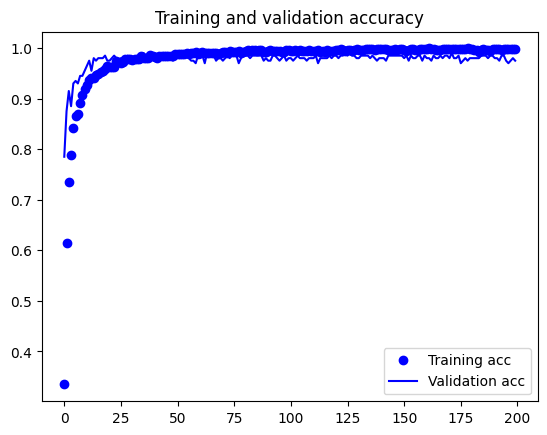

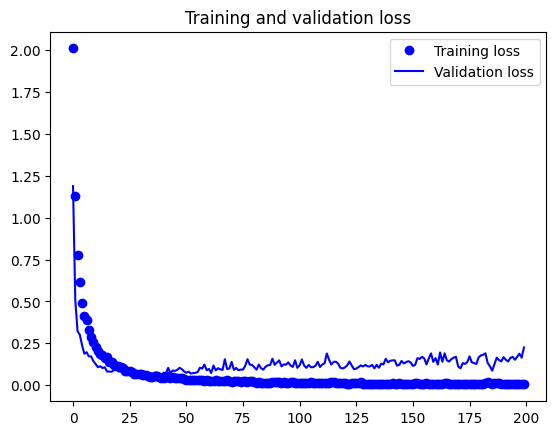

In [42]:
import matplotlib.pyplot as plt
%matplotlib inline

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()